In [1]:
import tensorflow as tf
print(tf.__version__)

/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2.20.0


In [2]:
pip install tensorflow numpy matplotlib

You should consider upgrading via the '/Users/vfosouza/Workspace/genai-health/genai-health-env/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install --upgrade tensorflow
%pip install --upgrade keras

You should consider upgrading via the '/Users/vfosouza/Workspace/genai-health/genai-health-env/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/vfosouza/Workspace/genai-health/genai-health-env/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2DTranspose

In [9]:
# Generator model
def build_generator():
    model = tf.keras.Sequential()
    model.add(layers.Dense(128, activation='relu', input_dim=100))
    model.add(layers.Reshape((4, 4, 8)))
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='sigmoid'))
    return model

In [10]:
# Discriminator model
def build_discriminator():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(32, kernel_size=4, strides=2, padding='same', input_shape=(32, 32, 1)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [11]:
# Compile GAN
generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [12]:
# Combined model GAN
discriminator.trainable = False
gan_input = layers.Input(shape=(100,))
x = generator(gan_input)
gan_output = discriminator(x)
gan = tf.keras.models.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

In [13]:
import numpy as np

def train_gan(generator, discriminator, gan, data, epochs=10000, batch_size=64):
    for epoch in range(epochs):
        # Train discriminator
        noise = np.random.normal(0, 1, (batch_size, 100))
        gen_images = generator.predict(noise)
        real_images = data[np.random.randint(0, data.shape[0], batch_size)]
        combined_images = np.concatenate([gen_images, real_images])
        labels = np.concatenate([np.zeros((batch_size, 1)), np.ones((batch_size, 1))])
        d_loss = discriminator.train_on_batch(combined_images, labels)

        # Train generator
        misleading_labels = np.ones((batch_size, 1))
        g_loss = gan.gan.train_on_batch(noise, misleading_labels)

        if epoch%1000 == 0:
            print(f"Epoch {epoch}, D Loss: {d_loss}, G Loss: {g_loss}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


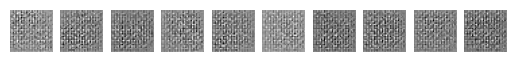

In [14]:
import matplotlib.pyplot as plt

def plot_generated_images(generator, n_images=10):
    noise = np.random.normal(0, 1, (n_images, 100))
    gen_images = generator.predict(noise)
    for i in range(n_images):
        plt.subplot(1, n_images, i+1)
        plt.imshow(gen_images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.show()

plot_generated_images(generator)